# Explore from first principles daily reforecast of financial time series group question

In [1]:
from call_local_llm import call_local_llm

In [5]:
def humor_me(question):
    txt = call_local_llm(question, 'mistral-small3.2:24b-instruct-2506-q4_K_M')
    print()
    print(txt)
    return txt

In [2]:
print(call_local_llm('Hello, world', 'mistral-small3.2:24b-instruct-2506-q4_K_M'))

START model mistral-small3.2:24b-instruct-2506-q4_K_M
model mistral-small3.2:24b-instruct-2506-q4_K_M minutes 0.1955233375231425
Hello! How can I assist you today?


In [3]:
flow = [38699, 38705, 38798, 38799, 38683, 38684, 38706, 38707, 38723]

In [4]:
import requests
from tqdm import tqdm
jsons = {}
for id in tqdm(flow):
    url = f"https://www.metaculus.com/api/posts/{id}/?format=json"
    response = requests.get(url)
    raw_text = response.text
    jsons[id] = raw_text

100%|█████████████████████████████████████████████| 9/9 [00:02<00:00,  3.71it/s]


In [9]:
import json
questions = {id: json.loads(jsons[id]) for id in flow}

In [6]:
id = flow[0]

In [11]:
question = questions[id]

In [21]:
group_title = question['title']

In [22]:
group_description = question['group_of_questions']['description']

In [23]:
group_resolution_criteria = question['group_of_questions']['resolution_criteria']

In [24]:
group_fine_print = question['group_of_questions']['fine_print']

In [25]:
question_title = question['group_of_questions']['questions'][0]['title']

In [29]:
p1 = f"""Describe in brief terms what is being asked for in this question: 

```group title
{group_title}
```

```group description
{group_description}
```

```group resolution criteria
{group_resolution_criteria}
```

```group fine print
{group_fine_print}
```

```individual question title
{question_title}
```
"""

In [30]:
a1 = humor_me(p1)

START model mistral-small3.2:24b-instruct-2506-q4_K_M
model mistral-small3.2:24b-instruct-2506-q4_K_M minutes 0.10314456621805827

The question is asking for the difference in stock price returns between Nvidia (NVDA) and Apple (AAPL) for the biweekly period from July 21 to August 1, 2025. Specifically, it wants to know how much Nvidia's stock price return will exceed Apple's during this period.

The resolution criteria specify that the difference will be calculated as:
\[ \text{NVDA\_return} - \text{AAPL\_return} \]

Where:
- NVDA_return is the percentage return of Nvidia's stock for the period.
- AAPL_return is the percentage return of Apple's stock for the period.

The returns are calculated using the adjusted closing prices (Adj Close) of the stocks on the last trading day before the start of the period (P₀) and on the last trading day of the period (P₁):
\[ \text{return} = 100 \times \frac{P1 - P0}{P0} \]

If Apple outperforms Nvidia, the result will be negative. The question also

In [41]:
p2 = f"""
Given that what I want to compute is as follows:

```task
{a1}
```

Please list the individual financial time series I need and write a python program to access them using the yfinance library.  
The program collects needed to do effective time series analysis for the defined forecast period.
The lookup should be for ONE YEAR PRIOR TO THE START OF THE FORECAST PERIOD.  It should NOT be for the forecast period itself."""

In [42]:
a2 = humor_me(p2)

START model mistral-small3.2:24b-instruct-2506-q4_K_M
model mistral-small3.2:24b-instruct-2506-q4_K_M minutes 0.29743136564890543

To compute the difference in stock price returns between Nvidia (NVDA) and Apple (AAPL) for the biweekly period from July 21 to August 1, 2025, you need the historical adjusted closing prices for both stocks for one year prior to the start of the forecast period. This means you need data from July 21, 2024, to July 21, 2025.

Here are the individual financial time series you need:
1. Adjusted closing prices for Nvidia (NVDA) from July 21, 2024, to July 21, 2025.
2. Adjusted closing prices for Apple (AAPL) from July 21, 2024, to July 21, 2025.

Below is a Python program that uses the `yfinance` library to fetch this data:

```python
import yfinance as yf
import pandas as pd

# Define the ticker symbols and the date range
tickers = ['NVDA', 'AAPL']
start_date = '2024-07-21'
end_date = '2025-07-21'

# Download the historical data
data = yf.download(tickers, st

In [34]:
def extract_python(txt):
    return txt.split('```python')[1].split('```')[0]

In [ ]:
c2 = extract_python(a2)

with open('c2.py', 'w') as f:
    f.write(c2)

In [46]:
!cat c2.py


import yfinance as yf
import pandas as pd

# Define the ticker symbols and the date range
tickers = ['NVDA', 'AAPL']
start_date = '2024-07-21'
end_date = '2025-07-21'

# Download the historical data
data = yf.download(tickers, start=start_date, end=end_date)['Adj Close']

# Save the data to CSV files
data['NVDA'].to_csv('NVDA_adj_close.csv')
data['AAPL'].to_csv('AAPL_adj_close.csv')

# Display the first few rows of the data
print("NVDA Adjusted Closing Prices:")
print(data['NVDA'].head())
print("\nAAPL Adjusted Closing Prices:")
print(data['AAPL'].head())


In [54]:
import yfinance as yf
import pandas as pd

# Define the ticker symbols and the date range
tickers = ['NVDA', 'AAPL']
start_date = '2024-07-21'
end_date = '2025-07-21'

# Download the historical data
data = yf.download(tickers, start=start_date, end=end_date, auto_adjust = True)['Close']

[*********************100%***********************]  2 of 2 completed


In [63]:
df = data

In [88]:
p3 = f"""You have a dataframe df of the most recent one year of daily training data.
The name of each column of df is a ticker.
The value of the column is the adjusted close price of the stock.
Describe the time series needed for the question, and write a program to compute the values of that time series given df.
NOTE: 
* We do not know and can not know the value of the time series for the period of the question
* Our job is to compute the historical value of the time series for the year prior to the period of the question.
* So we look at data for the prior year, not data for the period of the question, which we do not have.
* The program must assume that there is a year of data, not a year and a day, and generate the time series going forward from the first available row of data in df.
* We are asking for a time series on a sliding 10 business day basis of the 10-day return on NVDA minus the 10-day return on AAPL at the end of the 10 day period. Write a Python program which gives this time series from the original time series, where the new time series is the end of the 10 day period and the 10 day return difference, stepping the 10-day window forward one day at a time.
Here is information about the time series:

{a1}"""

In [89]:
a3 = humor_me(p3)

START model mistral-small3.2:24b-instruct-2506-q4_K_M
model mistral-small3.2:24b-instruct-2506-q4_K_M minutes 0.4491799314816793

To compute the time series of the 10-day return difference between NVDA and AAPL, we need to follow these steps:

1. **Understand the Time Series**: We need a sliding 10-business-day window where for each day, we calculate the 10-day return of NVDA and AAPL, then find the difference between these returns. The time series will be indexed by the end date of each 10-day period.

2. **Calculate 10-Day Returns**: For each 10-day period ending on day `t`, the 10-day return is calculated as:
   \[
   \text{return} = 100 \times \frac{\text{Adj Close at } t - \text{Adj Close at } t-10}{\text{Adj Close at } t-10}
   \]
   The difference is then:
   \[
   \text{NVDA\_return} - \text{AAPL\_return}
   \]

3. **Sliding Window**: The window slides forward one day at a time, starting from the 10th day of the data to the end of the data.

Here is the Python program to comput

In [90]:
c3 = extract_python(a3)

with open('c3.py', 'w') as f:
    f.write(c3)

In [92]:
import pandas as pd

def compute_return_difference(df):
    """
    Compute the 10-day return difference between NVDA and AAPL.

    Parameters:
    df (pd.DataFrame): DataFrame with columns as tickers and rows as dates.
                       Each cell contains the adjusted close price.

    Returns:
    pd.Series: Time series of the 10-day return difference, indexed by the end date.
    """
    # Ensure the DataFrame is sorted by date
    df = df.sort_index()

    # Initialize the result Series
    result = pd.Series(dtype=float)

    # Iterate over each possible end date of the 10-day period
    for end_date in df.index[9:]:  # Start from the 10th day
        start_date = df.index[df.index.get_loc(end_date) - 9]

        # Calculate 10-day returns for NVDA and AAPL
        nvda_return = 100 * (df.loc[end_date, 'NVDA'] - df.loc[start_date, 'NVDA']) / df.loc[start_date, 'NVDA']
        aapl_return = 100 * (df.loc[end_date, 'AAPL'] - df.loc[start_date, 'AAPL']) / df.loc[start_date, 'AAPL']

        # Calculate the difference
        return_diff = nvda_return - aapl_return

        # Add to the result Series
        result[end_date] = return_diff

    return result

In [93]:
df

Ticker,AAPL,NVDA
Date,,
2024-07-22,222.917480,123.500984
2024-07-23,223.962601,122.551277
2024-07-24,217.522705,114.213913
2024-07-25,216.477615,112.244545
2024-07-26,216.945419,113.024292
...,...,...
2025-07-01,207.820007,153.300003
2025-07-02,212.440002,157.250000
2025-07-03,213.550003,159.339996


In [97]:
df_10day_return_spread = compute_return_difference(df)

<Axes: >

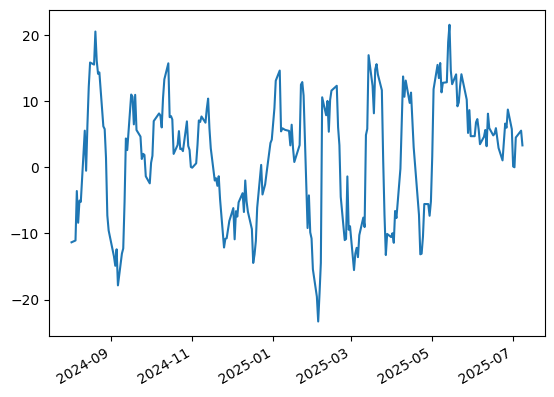

In [99]:
%matplotlib inline
import matplotlib.pylab as plt
df_10day_return_spread.plot()

<Axes: >

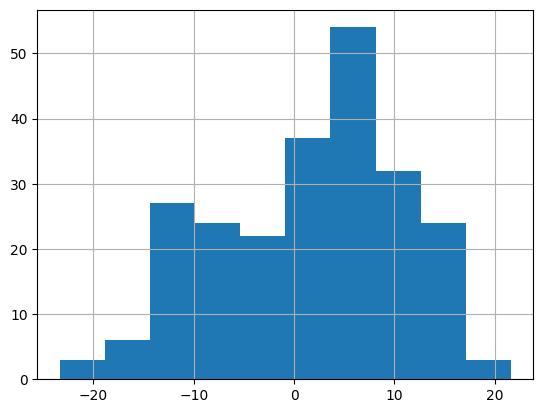

In [100]:
df_10day_return_spread.hist()

In [102]:
type(df_10day_return_spread)

pandas.core.series.Series

In [103]:
df_10day_return_spread.name = "Spread"

In [105]:
df_10day_return_spread

2024-08-02   -11.339139
2024-08-05   -11.064946
2024-08-06    -3.577480
2024-08-07    -8.381125
2024-08-08    -5.022062
                ...    
2025-07-01     0.143973
2025-07-02     0.022500
2025-07-03     4.524371
2025-07-07     5.565770
2025-07-08     3.333484
Name: Spread, Length: 232, dtype: float64

In [121]:
p4 =  f"""I have a pandas Series df_10day_return_spread, indexed by days and giving trailing 10 day return spread for each day.
Write a python program to do two things:

* Using the daily data, make a cumulative density function for the value range from the minimum observed spread to the maximum observed spread.
* Compute the 25th, 50th and 75th percentiles of this distribution and return them"""

In [122]:
a4 = humor_me(p4)

START model mistral-small3.2:24b-instruct-2506-q4_K_M
model mistral-small3.2:24b-instruct-2506-q4_K_M minutes 0.32426708539326987

To accomplish this task, we'll need to write a Python program that uses the pandas Series `df_10day_return_spread` to create a cumulative density function (CDF) and then compute the 25th, 50th, and 75th percentiles of the distribution. Here's how you can do it:

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def analyze_return_spread(series):
    """
    Analyze the return spread series to create a CDF and compute percentiles.

    Parameters:
    series (pd.Series): A pandas Series indexed by days with trailing 10-day return spread.

    Returns:
    dict: A dictionary containing the 25th, 50th, and 75th percentiles.
    """
    # Step 1: Create the CDF
    sorted_values = np.sort(series)
    cdf = np.arange(1, len(sorted_values) + 1) / len(sorted_values)

    # Step 2: Plot the CDF (optional)
    plt.figure(figsize=(10, 

In [123]:
c4 = extract_python(a4)

with open('c4.py', 'w') as f:
    f.write(c4)

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def analyze_return_spread(series):
    """
    Analyze the return spread series to create a CDF and compute percentiles.

    Parameters:
    series (pd.Series): A pandas Series indexed by days with trailing 10-day return spread.

    Returns:
    dict: A dictionary containing the 25th, 50th, and 75th percentiles.
    """
    # Step 1: Create the CDF
    sorted_values = np.sort(series)
    cdf = np.arange(1, len(sorted_values) + 1) / len(sorted_values)

    # Step 2: Plot the CDF (optional)
    plt.figure(figsize=(10, 6))
    plt.plot(sorted_values, cdf, marker='.', linestyle='none')
    plt.xlabel('10-Day Return Spread')
    plt.ylabel('Cumulative Probability')
    plt.title('Cumulative Density Function (CDF) of 10-Day Return Spread')
    plt.grid(True)
    plt.show()

    # Step 3: Compute the percentiles
    percentiles = {
        25: np.percentile(series, 25),
        50: np.percentile(series, 50),
        75: np.percentile(series, 75)
    }

    return percentiles

# Example usage:
# Assuming df_10day_return_spread is your pandas Series
# percentiles = analyze_return_spread(df_10day_return_spread)
# print(percentiles)

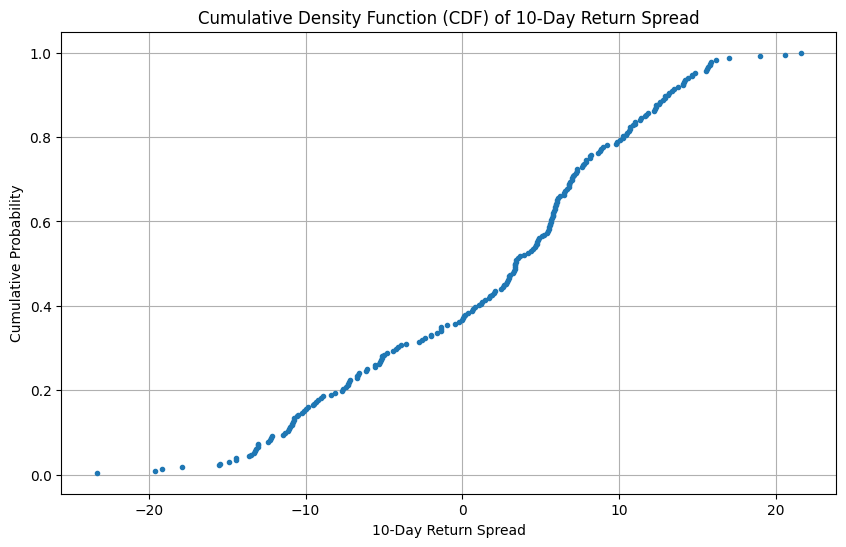

{25: -5.687696540864424, 50: 3.3848259913077854, 75: 8.141121731176657}

In [138]:
percentile_values = analyze_return_spread(df_10day_return_spread)
percentile_values

In [139]:
import re
import numpy as np

def ensure_min_increase(lst, min_step=5e-05):
    """
    Ensure each element in the list is at least `min_step` greater than the previous.
    If not, set it to previous + min_step.
    
    Args:
        lst (list of float): Input list of floats.
        min_step (float): Minimum required increase between elements.
        
    Returns:
        list of float: Adjusted list with minimum step enforced.
    """
    if not lst:
        return []
    result = [lst[0]]
    for num in lst[1:]:
        prev = result[-1]
        if num < prev + min_step:
            result.append(prev + min_step)
        else:
            result.append(num)
    return result


def generate_continuous_cdf(
    percentile_values: dict,
    open_upper_bound: bool,
    open_lower_bound: bool,
    upper_bound: float,
    lower_bound: float,
    zero_point: float | None,
) -> list[float]:
    """
    Returns: list[float]: A list of 201 float values representing the CDF.
    """

    percentile_max = max(float(key) for key in percentile_values.keys())
    percentile_min = min(float(key) for key in percentile_values.keys())
    range_min = lower_bound
    range_max = upper_bound
    range_size = range_max - range_min
    buffer = 1 if range_size > 100 else 0.01 * range_size

    # Adjust any values that are exactly at the bounds
    for percentile, value in list(percentile_values.items()):
        if not open_lower_bound and value <= range_min + buffer:
            percentile_values[percentile] = range_min + buffer
        if not open_upper_bound and value >= range_max - buffer:
            percentile_values[percentile] = range_max - buffer

    # Set cdf values outside range
    if open_upper_bound:
        if range_max > percentile_values[percentile_max]:
            percentile_values[int(100 - (0.5 * (100 - percentile_max)))] = range_max
    else:
        percentile_values[100] = range_max

    # Set cdf values outside range
    if open_lower_bound:
        if range_min < percentile_values[percentile_min]:
            percentile_values[int(0.5 * percentile_min)] = range_min
    else:
        percentile_values[0] = range_min

    sorted_percentile_values = dict(sorted(percentile_values.items()))

    # Normalize percentile keys
    normalized_percentile_values = {}
    for key, value in sorted_percentile_values.items():
        percentile = float(key) / 100
        normalized_percentile_values[percentile] = value


    value_percentiles = {
        value: key for key, value in normalized_percentile_values.items()
    }

    # function for log scaled questions
    def generate_cdf_locations(range_min, range_max, zero_point):
        if zero_point is None or np.isnan(zero_point):
            scale = lambda x: range_min + (range_max - range_min) * x
        else:
            deriv_ratio = (range_max - zero_point) / (range_min - zero_point)
            scale = lambda x: range_min + (range_max - range_min) * (
                deriv_ratio**x - 1
            ) / (deriv_ratio - 1)
        return [scale(x) for x in np.linspace(0, 1, 201)]

    cdf_xaxis = generate_cdf_locations(range_min, range_max, zero_point)

    def linear_interpolation(x_values, xy_pairs):
        # Sort the xy_pairs by x-values
        sorted_pairs = sorted(xy_pairs.items())

        # Extract sorted x and y values
        known_x = [pair[0] for pair in sorted_pairs]
        known_y = [pair[1] for pair in sorted_pairs]

        # Initialize the result list
        y_values = []

        for x in x_values:
            # Check if x is exactly in the known x values
            if x in known_x:
                y_values.append(known_y[known_x.index(x)])
            else:
                # Find the indices of the two nearest known x-values
                i = 0
                while i < len(known_x) and known_x[i] < x:
                    i += 1

                # If x is outside the range of known x-values, use the nearest endpoint
                if i == 0:
                    y_values.append(known_y[0])
                elif i == len(known_x):
                    y_values.append(known_y[-1])
                else:
                    # Perform linear interpolation
                    x0, x1 = known_x[i - 1], known_x[i]
                    y0, y1 = known_y[i - 1], known_y[i]

                    # Linear interpolation formula
                    y = y0 + (x - x0) * (y1 - y0) / (x1 - x0)
                    y_values.append(y)

        return y_values

    continuous_cdf = linear_interpolation(cdf_xaxis, value_percentiles)
    continuous_cdf = ensure_min_increase(continuous_cdf)
    return continuous_cdf


In [140]:
percentile_values

{25: -5.687696540864424, 50: 3.3848259913077854, 75: 8.141121731176657}

In [141]:
import pandas as pd

row = pd.Series()

import os, requests
from load_secrets import load_secrets
load_secrets()

# @title Helper functions
METACULUS_TOKEN = os.getenv('METACULUS_TOKEN')
AUTH_HEADERS = {"headers": {"Authorization": f"Token {METACULUS_TOKEN}"}}
API_BASE_URL = "https://www.metaculus.com/api"

def create_forecast_payload(
    forecast: float | dict[str, float] | list[float],
    question_type: str,
) -> dict:
    """
    Accepts a forecast and generates the api payload in the correct format.

    If the question is binary, forecast must be a float.
    If the question is multiple choice, forecast must be a dictionary that
      maps question.options labels to floats.
    If the question is numeric, forecast must be a dictionary that maps
      quartiles or percentiles to datetimes, or a 201 value cdf.
    """
    if question_type == "binary":
        return {
            "probability_yes": forecast,
            "probability_yes_per_category": None,
            "continuous_cdf": None,
        }
    if question_type == "multiple_choice":
        return {
            "probability_yes": None,
            "probability_yes_per_category": forecast,
            "continuous_cdf": None,
        }
    # numeric or date
    return {
        "probability_yes": None,
        "probability_yes_per_category": None,
        "continuous_cdf": forecast,
    }

def post_question_prediction(question_id: int, forecast_payload: dict) -> None:
    """
    Post a forecast on a question.
    """
    url = f"{API_BASE_URL}/questions/forecast/"
    response = requests.post(
        url,
        json=[
            {
                "question": question_id,
                **forecast_payload,
            },
        ],
        **AUTH_HEADERS,  # type: ignore
    )
    print(f"Prediction Post status code: {response.status_code}")
    if not response.ok:
        raise RuntimeError(response.text)


def post_question_comment(post_id: int, comment_text: str) -> None:
    """
    Post a comment on the question page as the bot user.
    """
    response = requests.post(
        f"{API_BASE_URL}/comments/create/",
        json= {
            "text": comment_text,
            "parent": None,
            "included_forecast": True,
            "is_private": True,
            "on_post": post_id,
        },
        **AUTH_HEADERS,  # type: ignore
    )
    if not response.ok:
        raise RuntimeError(response.text)

def post_forecast(row):
    question_id = int(row.id_of_question)
    post_id = int(row.id_of_post)
    question_type = row.question_type
    forecast = row.prediction
    comment = row.forecast
    forecast_payload = create_forecast_payload(forecast, question_type)
    post_question_prediction(question_id, forecast_payload)
    post_question_comment(post_id, comment)
    print("Posted forecast for", question_id)

In [142]:
percentile_values

{25: -5.687696540864424, 50: 3.3848259913077854, 75: 8.141121731176657}

In [143]:
row['id_of_question'] = 37964

row['id_of_post'] = 38699

row['question_type'] = 'numeric'

row['forecast'] = """We compute the history of the 10-day returns of AAPL and NVDA for one year prior to today.
We then compute the daily difference of those histories.
Then we make an empirical cumulative density function from the sorted daily differences.
Then we report the 25, 50 and 75th percentiles of this distribution as our forecast.
"""

In [144]:
row['question_open_upper_bound'] =  True
row['question_open_lower_bound'] =  True
row['question_scaling_range_max'] =  20.0
row['question_scaling_range_min'] =  -20.0
row['question_scaling_zero_point'] =  None

In [ ]:
percentile_values

In [145]:
prediction = generate_continuous_cdf(
                    percentile_values.copy(),
                    row.question_open_upper_bound,
                    row.question_open_lower_bound,
                    row.question_scaling_range_max,
                    row.question_scaling_range_min,
                    row.question_scaling_zero_point)

In [146]:
percentile_values

{25: -5.687696540864424, 50: 3.3848259913077854, 75: 8.141121731176657}

In [147]:
prediction

[0.12,
 0.12181661883247759,
 0.12363323766495518,
 0.12544985649743282,
 0.1272664753299104,
 0.129083094162388,
 0.1308997129948656,
 0.1327163318273432,
 0.13453295065982082,
 0.1363495694922984,
 0.138166188324776,
 0.13998280715725359,
 0.1417994259897312,
 0.14361604482220883,
 0.1454326636546864,
 0.147249282487164,
 0.1490659013196416,
 0.1508825201521192,
 0.15269913898459683,
 0.15451575781707444,
 0.15633237664955202,
 0.1581489954820296,
 0.15996561431450723,
 0.16178223314698484,
 0.16359885197946242,
 0.16541547081194002,
 0.1672320896444176,
 0.16904870847689524,
 0.17086532730937284,
 0.17268194614185042,
 0.17449856497432803,
 0.1763151838068056,
 0.17813180263928324,
 0.17994842147176085,
 0.18176504030423843,
 0.18358165913671604,
 0.18539827796919361,
 0.18721489680167125,
 0.18903151563414883,
 0.19084813446662646,
 0.19266475329910404,
 0.19448137213158168,
 0.19629799096405925,
 0.19811460979653683,
 0.19993122862901447,
 0.20174784746149205,
 0.20356446629396965

In [148]:
row['prediction'] = prediction

def post_forecast(row):
    question_id = int(row.id_of_question)
    post_id = int(row.id_of_post)
    question_type = row.question_type
    forecast = row.prediction
    comment = row.forecast
    forecast_payload = create_forecast_payload(forecast, question_type)
    post_question_prediction(question_id, forecast_payload)
    post_question_comment(post_id, comment)
    print("Posted forecast for", question_id)

post_forecast(row)

Prediction Post status code: 201
Posted forecast for 37964
